In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob as gb
from sklearn.metrics import confusion_matrix, classification_report
import itertools

2025-05-05 14:33:34.751351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746455614.951454      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746455615.006038      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
directory = "/kaggle/input/monkeypox-skin-lesion-dataset/Augmented Images/Augmented Images"

# Dataset loading
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    validation_split=0.1,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = train_dataset.class_names
num_classes = len(class_names)

# Class weight calculation
data_imbalance = [len(gb.glob(os.path.join(directory, class_folder, '*.*'))) for class_folder in class_names]
total_images = sum(data_imbalance)
class_weight = {
    i: (1.0 / count) * (total_images / len(data_imbalance))
    for i, count in enumerate(data_imbalance)
}


Found 3192 files belonging to 2 classes.
Using 2873 files for training.


I0000 00:00:1746455632.280662      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3192 files belonging to 2 classes.
Using 319 files for validation.


In [3]:
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal"),
#     tf.keras.layers.RandomRotation(0.1),
#     tf.keras.layers.RandomZoom(0.1),
#     tf.keras.layers.RandomContrast(0.1),
# ])


In [4]:
# Model config
model_name = "deit_tiny_patch16_224"
input_resolution = 224

# Normalization
norm_layer = tf.keras.layers.Normalization(
    mean=[0.485 * 255, 0.456 * 255, 0.406 * 255],
    variance=[(0.229 * 255) ** 2, (0.224 * 255) ** 2, (0.225 * 255) ** 2],
)

import tensorflow as tf
import tensorflow_hub as hub

def build_deit_model():
    model_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"  # feature extractor
    input_shape = (224, 224, 3)
    num_classes = len(class_names)  # replace with actual number of classes

    inputs = tf.keras.Input(shape=input_shape)

    # Wrap the hub.KerasLayer call inside a Lambda to avoid KerasTensor issues
    hub_module = hub.KerasLayer(model_url, trainable=True)

    def hub_forward(x):
        return hub_module(x)

    features = tf.keras.layers.Lambda(hub_forward)(inputs)
    x = tf.keras.layers.Dropout(0.3)(features)
    outputs = tf.keras.layers.Dense(num_classes, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


In [5]:
model = build_deit_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


model.summary()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight=class_weight
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 768)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 768)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │           1,538 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,538 (6.01 KB)

 Trainable params: 1,538 (6.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


I0000 00:00:1746455679.626507      96 service.cc:148] XLA service 0x7e74d800d5c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746455679.627243      96 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746455680.678243      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/90 ━━━━━━━━━━━━━━━━━━━━ 18:39 13s/step - accuracy: 0.5938 - loss: 0.9916

I0000 00:00:1746455683.471875      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


90/90 ━━━━━━━━━━━━━━━━━━━━ 38s 281ms/step - accuracy: 0.5484 - loss: 1.0330 - val_accuracy: 0.5893 - val_loss: 0.6847
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.5627 - loss: 1.0301 - val_accuracy: 0.5987 - val_loss: 0.6454
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.5919 - loss: 0.9366 - val_accuracy: 0.5987 - val_loss: 0.6793
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.5688 - loss: 0.9775 - val_accuracy: 0.6332 - val_loss: 0.6367
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.5710 - loss: 0.9542 - val_accuracy: 0.6301 - val_loss: 0.6398
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.5713 - loss: 0.9520 - val_accuracy: 0.6583 - val_loss: 0.6141
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.5627 - loss: 0.9607 - val_accuracy: 0.6426 - val_loss: 0.6202
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.5886 - loss: 0.9016 - val_accuracy: 0.661

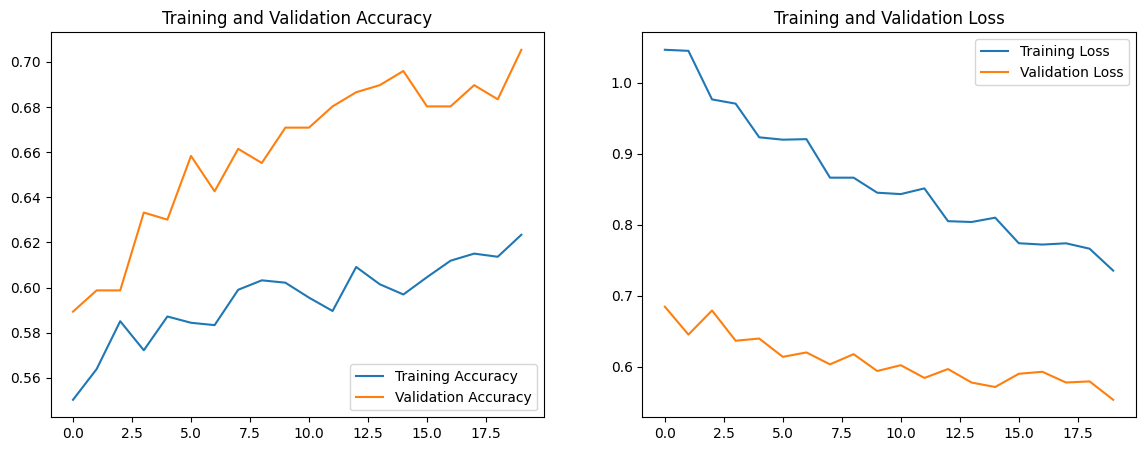

In [6]:
def plot_training(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title("Training and Validation Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title("Training and Validation Loss")
    plt.show()

plot_training(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


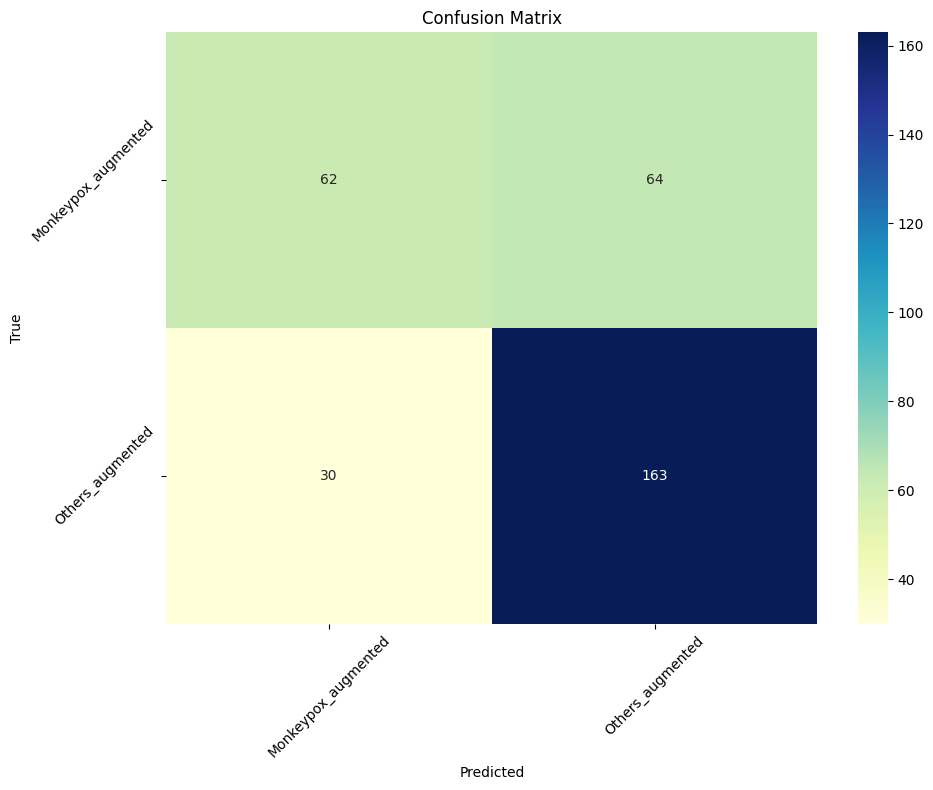


Classification Report:

                     precision    recall  f1-score   support

Monkeypox_augmented       0.67      0.49      0.57       126
   Others_augmented       0.72      0.84      0.78       193

           accuracy                           0.71       319
          macro avg       0.70      0.67      0.67       319
       weighted avg       0.70      0.71      0.69       319



In [7]:
# Get predictions
y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="YlGnBu")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
